In [19]:
""" Find all the read out err
1. raed time_unzip_take.csv 
2. read time_pwv_take*.csv to see read errors(when time is zero) & print total time take(Total time taken)

"""

import pandas as pd
import glob 

#Create txt to record errors
with open('readOutErr.txt', 'w') as f:
    f.write("Read Out Errors:\n\n")

#Archive Errors
#open the time_unzip_take.csv
# data = pd.read_csv('saveCSV/time_unzip_take.csv', dtype={"TIME": str,"take TIME (seconds)": float})
# for i in range(len(data)):
#     if data['TIME'][i].startswith('unzip'):
#         if data['take TIME (seconds)'][i] < 0.03:
#             with open('readOutErr.txt', 'a+') as f:
#                 #print(f"{data['TIME'][i]} ")
#                 f.write(f"{data['TIME'][i]}\t{data['take TIME (seconds)'][i]}\n")
#             f.close()
# print("Archive Errors saved to readOutErr.txt")

#find all time_pwv_take*.csv files
files = glob.glob('saveCSV/time_pwv_take*.csv')
  
#save all output to a file
with open('readOutErr.txt', 'a+') as f:
    for file in files:
        #print(f"Processing file: {file}")
        
        df = pd.read_csv(file)
        zero_time = df[df['take TIME (seconds)'] == 0]
        if not zero_time.empty:
            f.write(f"\nProcessing file: {file}\n")
            f.write(f"File: {file} has zero time values:\n")
            f.write(zero_time.to_string() + '\n')
    
    f.write("\nTotal time taken for each file:\n\n")
    
    total_num = 0
    for file in files:
        df = pd.read_csv(file)
        f.write(f"For {file}\nTotal time taken: {df['TIME'].tolist()[-1]}\n")
        num = len(df)
        total_num += num/7
        f.write(f"About {num/7:.0f} rows\n\n")
    print(f"Total number of rows processed: {total_num}")
f.close()


print("Output saved to output.txt")

            



Total number of rows processed: 11014.57142857143
Output saved to output.txt


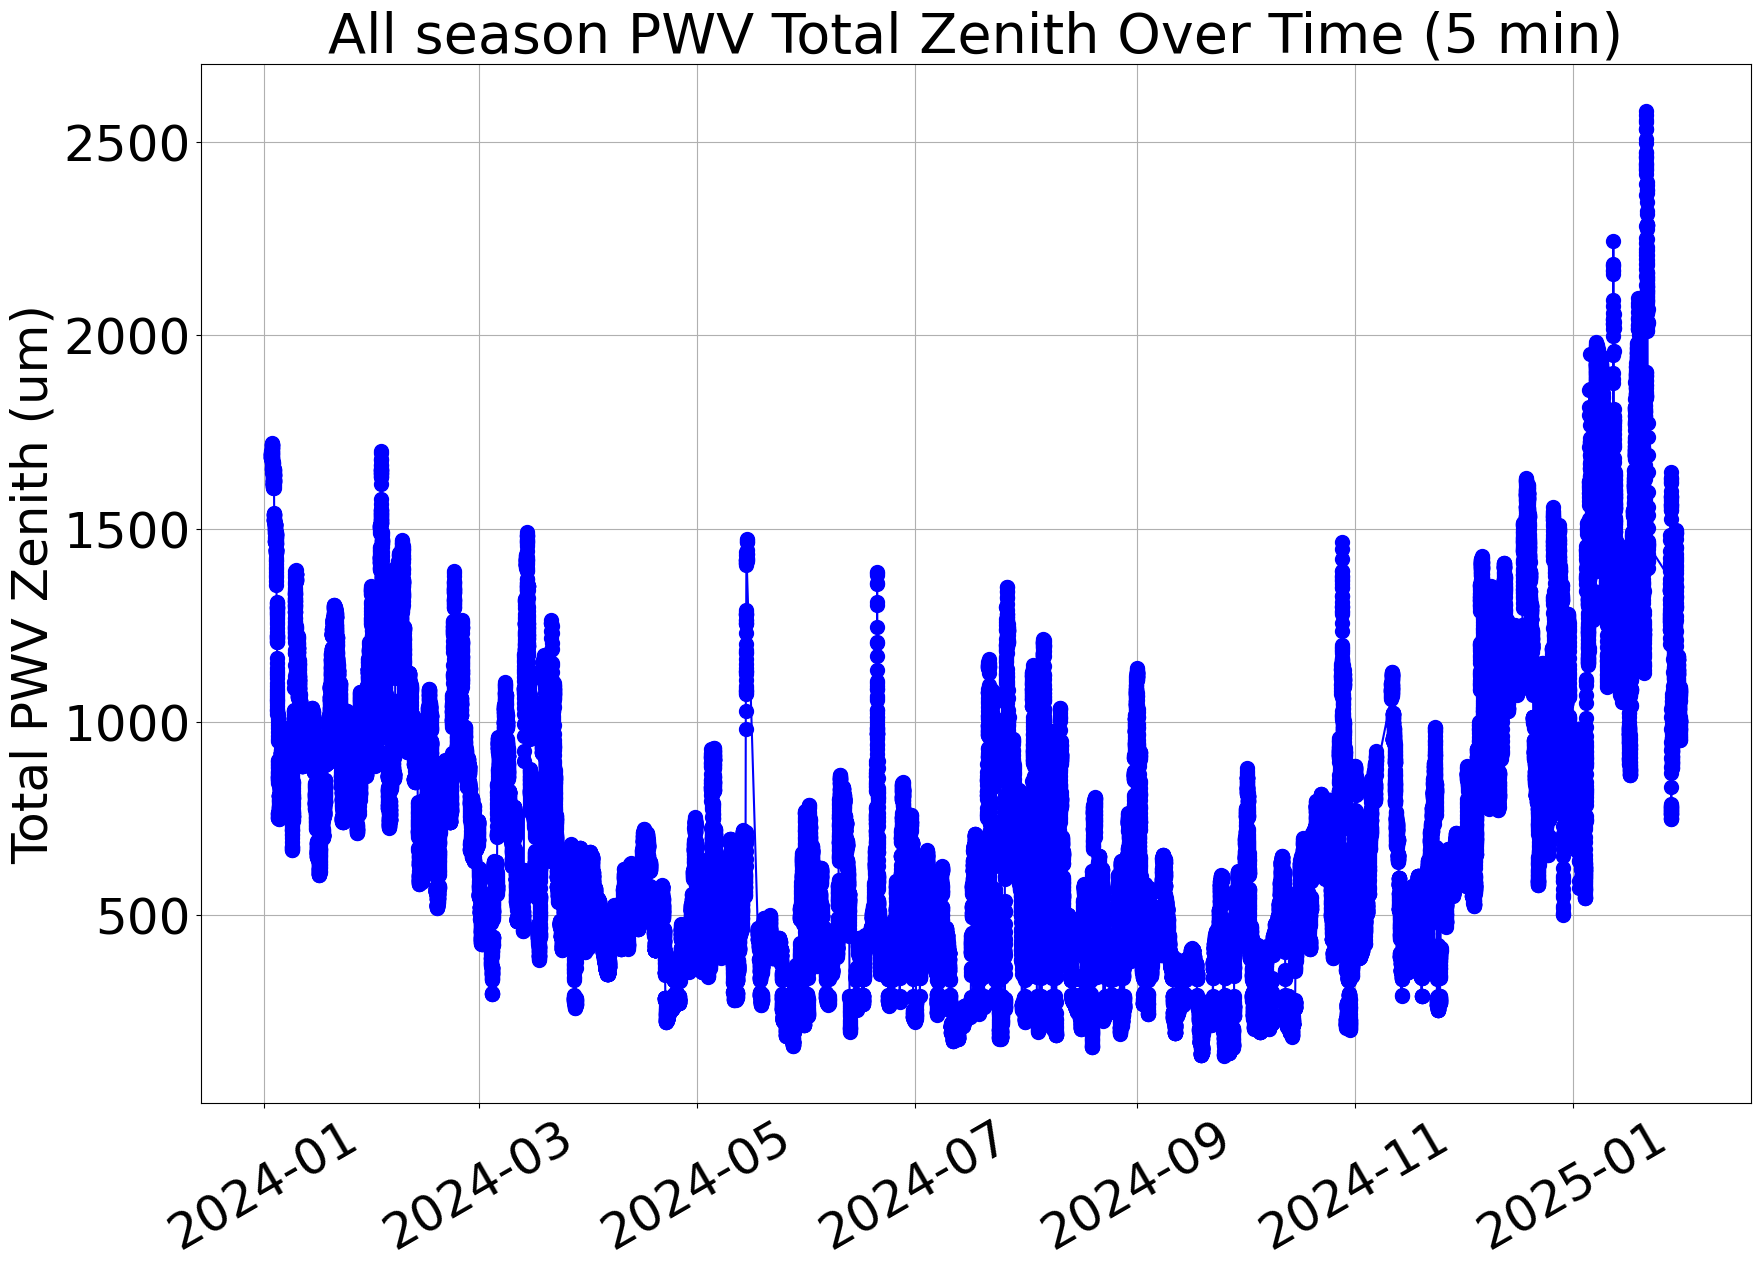

In [9]:
# make plots
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime
import glob 

#Winter Dec Jan Feb
#Spring Mar Apr May
#Summer Jun Jul Aug
#Autumn Sep Oct Nov

seasons = ['All']
#,'Winter24', 'Spring', 'Summer', 'Autumn','Winter25'

files = glob.glob('saveCSV/time_pwv_2*.csv')

#files = ['saveCSV/time_pwv_2401.csv', 'saveCSV/time_pwv_2402.csv']

#files = ['saveCSV/time_pwv_2403.csv', 'saveCSV/time_pwv_2404.csv', 'saveCSV/time_pwv_2405.csv']

#files = ['saveCSV/time_pwv_2406.csv', 'saveCSV/time_pwv_2407.csv', 'saveCSV/time_pwv_2408.csv']

#files = ['saveCSV/time_pwv_2409.csv', 'saveCSV/time_pwv_2410.csv', 'saveCSV/time_pwv_2411.csv']
#files = ['saveCSV/time_pwv_2412.csv', 'saveCSV/time_pwv_2501.csv']

#files = ['saveCSV/time_pwv_2407.csv']

season = "All_5min"
TIME = []
PWV_TOTAL_zenith = []
PWV_TOTAL_line_of_sight = []

for file in files:
    df = pd.read_csv(file, dtype={'DATE(YYYYMMDD)': str, 'START TIME(HHMMSS.Microsec)': str, 'PWV TOTAL zenith': str})
    df['TIME'] = pd.to_datetime(df['DATE(YYYYMMDD)'] + ' ' + df['START TIME(HHMMSS.Microsec)'], format='%Y%m%d %H%M%S.%f')
    df = df.sort_values(by='TIME') 
    TIME.extend(df['TIME'].tolist())

    df['PWV TOTAL zenith'] = df['PWV TOTAL zenith'].str.replace(' um_pwv', '').astype(float)
    df['PWV TOTAL line-of-sight'] = df['PWV TOTAL line-of-sight'].str.replace(' um_pwv', '').astype(float)
    PWV_TOTAL_zenith.extend(df['PWV TOTAL zenith'].tolist())
    PWV_TOTAL_line_of_sight.extend(df['PWV TOTAL line-of-sight'].tolist())

# plot the data
plt.figure(figsize=(40/2, 27/2))
plt.plot(TIME, PWV_TOTAL_zenith, marker='o', linestyle='-', color='b', markersize=10)
plt.title(f'All season PWV Total Zenith Over Time (5 min)', fontsize=40)
plt.ylabel('Total PWV Zenith (um)', fontsize=36)
plt.xticks(rotation=30, fontsize=36)
plt.yticks(fontsize=36)
plt.grid()
#plt.legend([f'Data range: {TIME[0]} → {TIME[-1]}'], loc='upper left', fontsize=32)
plt.savefig(f'saveCSV/plots/{season}_pwv_total_zenith_over_time1007.png', dpi=450)
plt.savefig(f'saveCSV/plots/{season}_pwv_total_zenith_over_time.svg')
plt.show()
plt.close()

# plt.figure(figsize=(40, 20))
# plt.plot(TIME, PWV_TOTAL_line_of_sight, marker='o', linestyle='-', color='r', markersize=10)
# plt.title(f'{season} PWV Total Line-of-Sight Over Time', fontsize=48)
# plt.xlabel('Time', fontsize=40)
# plt.ylabel('Total PWV Line-of-Sight (um)', fontsize=40)
# plt.xticks(rotation=45, fontsize=36)
# plt.yticks(fontsize=36)
# plt.grid()
# plt.legend([f'Data range: {TIME[0]} → {TIME[-1]}'], loc='upper left', fontsize=32)
# plt.savefig(f'saveCSV/plots/{season}_pwv_total_line_of_sight_over_time.png', dpi=300)
# #plt.savefig(f'saveCSV/plots/{season}_pwv_total_line_of_sight_over_time.svg')
# plt.show()
# plt.close()

# plt.figure(figsize=(40/2, 22/2))
# plt.hist(PWV_TOTAL_zenith, bins=50, color='blue', alpha=0.7)
# plt.title(f'All season Histogram of PWV Total Zenith', fontsize=40)
# plt.xlabel('Total PWV Zenith (um)', fontsize=36) 
# plt.ylabel('Number of Occurrences', fontsize=36)
# plt.xticks(fontsize=36)
# plt.yticks(fontsize=36)
# #plt.legend([f'Data range: {TIME[0]} → {TIME[-1]}'], loc='upper right', fontsize=32)
# plt.grid()
# plt.savefig(f'saveCSV/plots/{season}_histogram_pwv_total_zenith.png', dpi=500)
# plt.savefig(f'saveCSV/plots/{season}_histogram_pwv_total_zenith1007.svg')
# plt.show()
# plt.close()


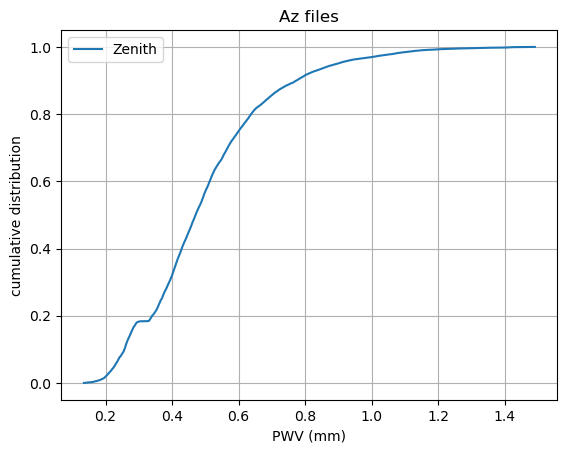

Data from  \t PWV(mm)    25%    50%    75%
 MERRA-2               0.231  0.321  0.448
 Az file               0.368  0.471  0.600


In [21]:
# make Cumulative Distribution Function (CDF) plots
#excluding summer  months: November–February for the Southern Hemisphere

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#

files = ['saveCSV/time_pwv_2403.csv', 'saveCSV/time_pwv_2404.csv', 
        'saveCSV/time_pwv_2405.csv',
        'saveCSV/time_pwv_2406.csv', 'saveCSV/time_pwv_2407.csv', 
        'saveCSV/time_pwv_2408.csv',
        'saveCSV/time_pwv_2409.csv', 'saveCSV/time_pwv_2410.csv']

season = "Excluding Summer"
TIME = []
PWV_TOTAL_zenith = []
PWV_TOTAL_line_of_sight = []

for file in files:
    df = pd.read_csv(file, dtype={'DATE(YYYYMMDD)': str, 'START TIME(HHMMSS.Microsec)': str, 'PWV TOTAL zenith': str})
    df['TIME'] = pd.to_datetime(df['DATE(YYYYMMDD)'] + ' ' + df['START TIME(HHMMSS.Microsec)'], format='%Y%m%d %H%M%S.%f')
    df = df.sort_values(by='TIME') 
    TIME.extend(df['TIME'].tolist())

    df['PWV TOTAL zenith'] = df['PWV TOTAL zenith'].str.replace(' um_pwv', '').astype(float)
    df['PWV TOTAL line-of-sight'] = df['PWV TOTAL line-of-sight'].str.replace(' um_pwv', '').astype(float)
    PWV_TOTAL_zenith.extend(df['PWV TOTAL zenith'].tolist())
    PWV_TOTAL_line_of_sight.extend(df['PWV TOTAL line-of-sight'].tolist())

# plt.figure(figsize=(20, 10))
# plt.plot(TIME, PWV_TOTAL_zenith, marker='o', linestyle='-', color='b')
# plt.title(f'{season} PWV Total Zenith Over Time')
# plt.xlabel('Time')
# plt.ylabel('Total PWV Zenith (um)')
# plt.xticks(rotation=45)
# plt.grid()
# #plt.show()
# plt.close()


#plot cdf
PWV_TOTAL_zenith_sorted = np.sort(PWV_TOTAL_zenith)/1000
PWV_TOTAL_line_of_sight_sorted = np.sort(PWV_TOTAL_line_of_sight)/1000
cdf_zen = np.arange(1, len(PWV_TOTAL_zenith_sorted)+1) / len(PWV_TOTAL_zenith_sorted)
cdf_los = np.arange(1, len(PWV_TOTAL_line_of_sight_sorted)+1) / len(PWV_TOTAL_line_of_sight_sorted)

plt.plot(PWV_TOTAL_zenith_sorted, cdf_zen, linestyle='-',label='Zenith')
#plt.plot(PWV_TOTAL_line_of_sight_sorted, cdf_los, linestyle='-',label='Line of Sight')
plt.xlabel('PWV (mm)')
plt.ylabel('cumulative distribution')
plt.title('Az files')
plt.legend()
plt.grid(True)
plt.savefig(f'saveCSV/0807 1st run/plots/{season}_cdf_pwv_total_zenith_line_of_sight.png', dpi=300)
plt.savefig(f'saveCSV/0807 1st run/plots/{season}_cdf_pwv_total_zenith_line_of_sight.svg')
plt.show()


q1 = np.percentile(PWV_TOTAL_zenith_sorted, 25)  # 25th percentile
q2 = np.percentile(PWV_TOTAL_zenith_sorted, 50)  # 50th percentile (median)
q3 = np.percentile(PWV_TOTAL_zenith_sorted, 75)  # 75th percentile

# print(f"Q1 (25%): {q1}")
# print(f"Q2 (Median, 50%): {q2}")
# print(f"Q3 (75%): {q3}")



data = {
    "Data from": [" MERRA-2 "," Az file "],
    " \\t PWV(mm)":["",""],
    "25%": [0.231, f"{q1:.3f}"],
    "50%": [0.321, f"{q2:.3f}"],
    "75%": [0.448, f"{q3:.3f}"]
}

df = pd.DataFrame(data)
print(df.to_string(index=False))

Fitted exponential: y = 27.522 * e^(-0.369x)


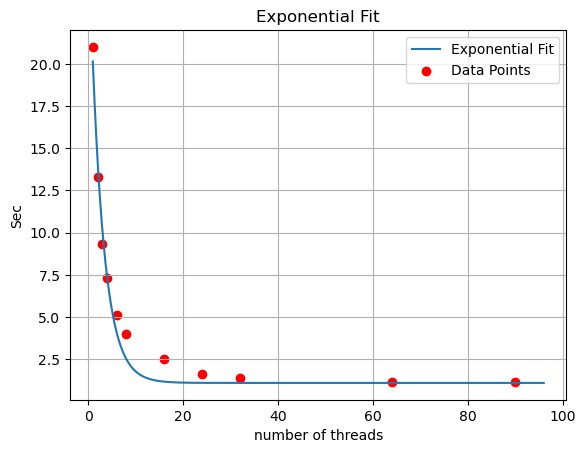

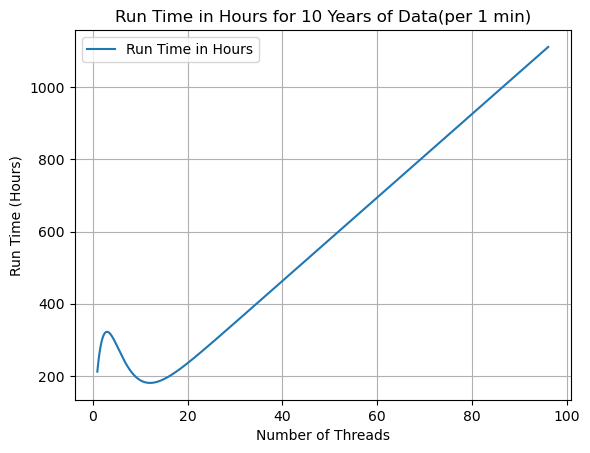

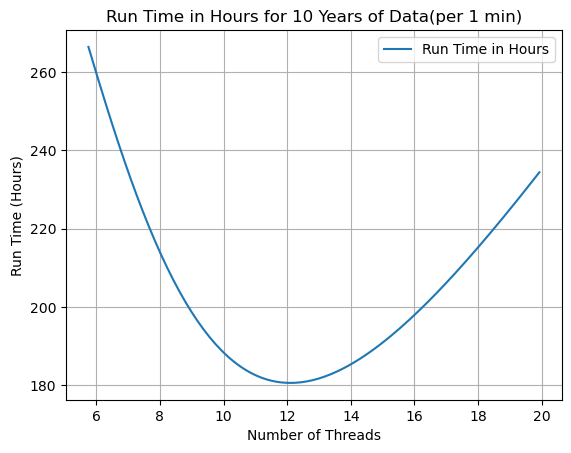

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Define the exponential function
def exp_func(x, a, b):
    return a * np.exp(b * x) + 1.1

# Given data points
x_data = np.array([1,   2,  3,      4,   6, 8, 16,  24,   32, 64,   90])
t_data = np.array([21, 13.3, 9.3, 7.3, 5.1, 4, 2.5, 1.6, 1.4, 1.15, 1.15])


h_data = (t_data * 500 * 6) / 3600  # Convert to hours
#print("Hours data: ", h_data)

# Fit the exponential model
params, _ = curve_fit(exp_func, x_data, t_data, p0=(0.1, -0.1))  # p0 is initial guess
a, b = params
print(f"Fitted exponential: y = {a:.3f} * e^({b:.3f}x)")

# Generate smooth curve for plotting
x = np.linspace(1, 96, 1000)
t = exp_func(x, a, b)
#print("Fitted time data: ", t)
# h = (t * 500*6)/3600 

# Plot
plt.plot(x, t, label='Exponential Fit')
plt.scatter(x_data, t_data, color='red', label='Data Points')
plt.title("Exponential Fit")
plt.xlabel("number of threads")
plt.ylabel("Sec")
plt.grid(True)
plt.legend()
plt.show()
plt.close()

#For time take in hours to data 10 years'data 1 mins each
num_dat = 500*60 #one month 
num_sys_run = 120 / (95/x) #num of month run together
#print(f"Number of months run together: {num_sys_run}")
run_time = (num_dat * num_sys_run * t) / 3600  # Convert to hours

plt.plot(x[0:], run_time[0:], label='Run Time in Hours')
plt.title("Run Time in Hours for 10 Years of Data(per 1 min)")
plt.xlabel("Number of Threads")
plt.ylabel("Run Time (Hours)")
plt.grid(True)
plt.legend()
plt.show()

plt.plot(x[50:200], run_time[50:200], label='Run Time in Hours')
plt.title("Run Time in Hours for 10 Years of Data(per 1 min)")
plt.xlabel("Number of Threads")
plt.ylabel("Run Time (Hours)")
plt.grid(True)
plt.legend()
plt.show()




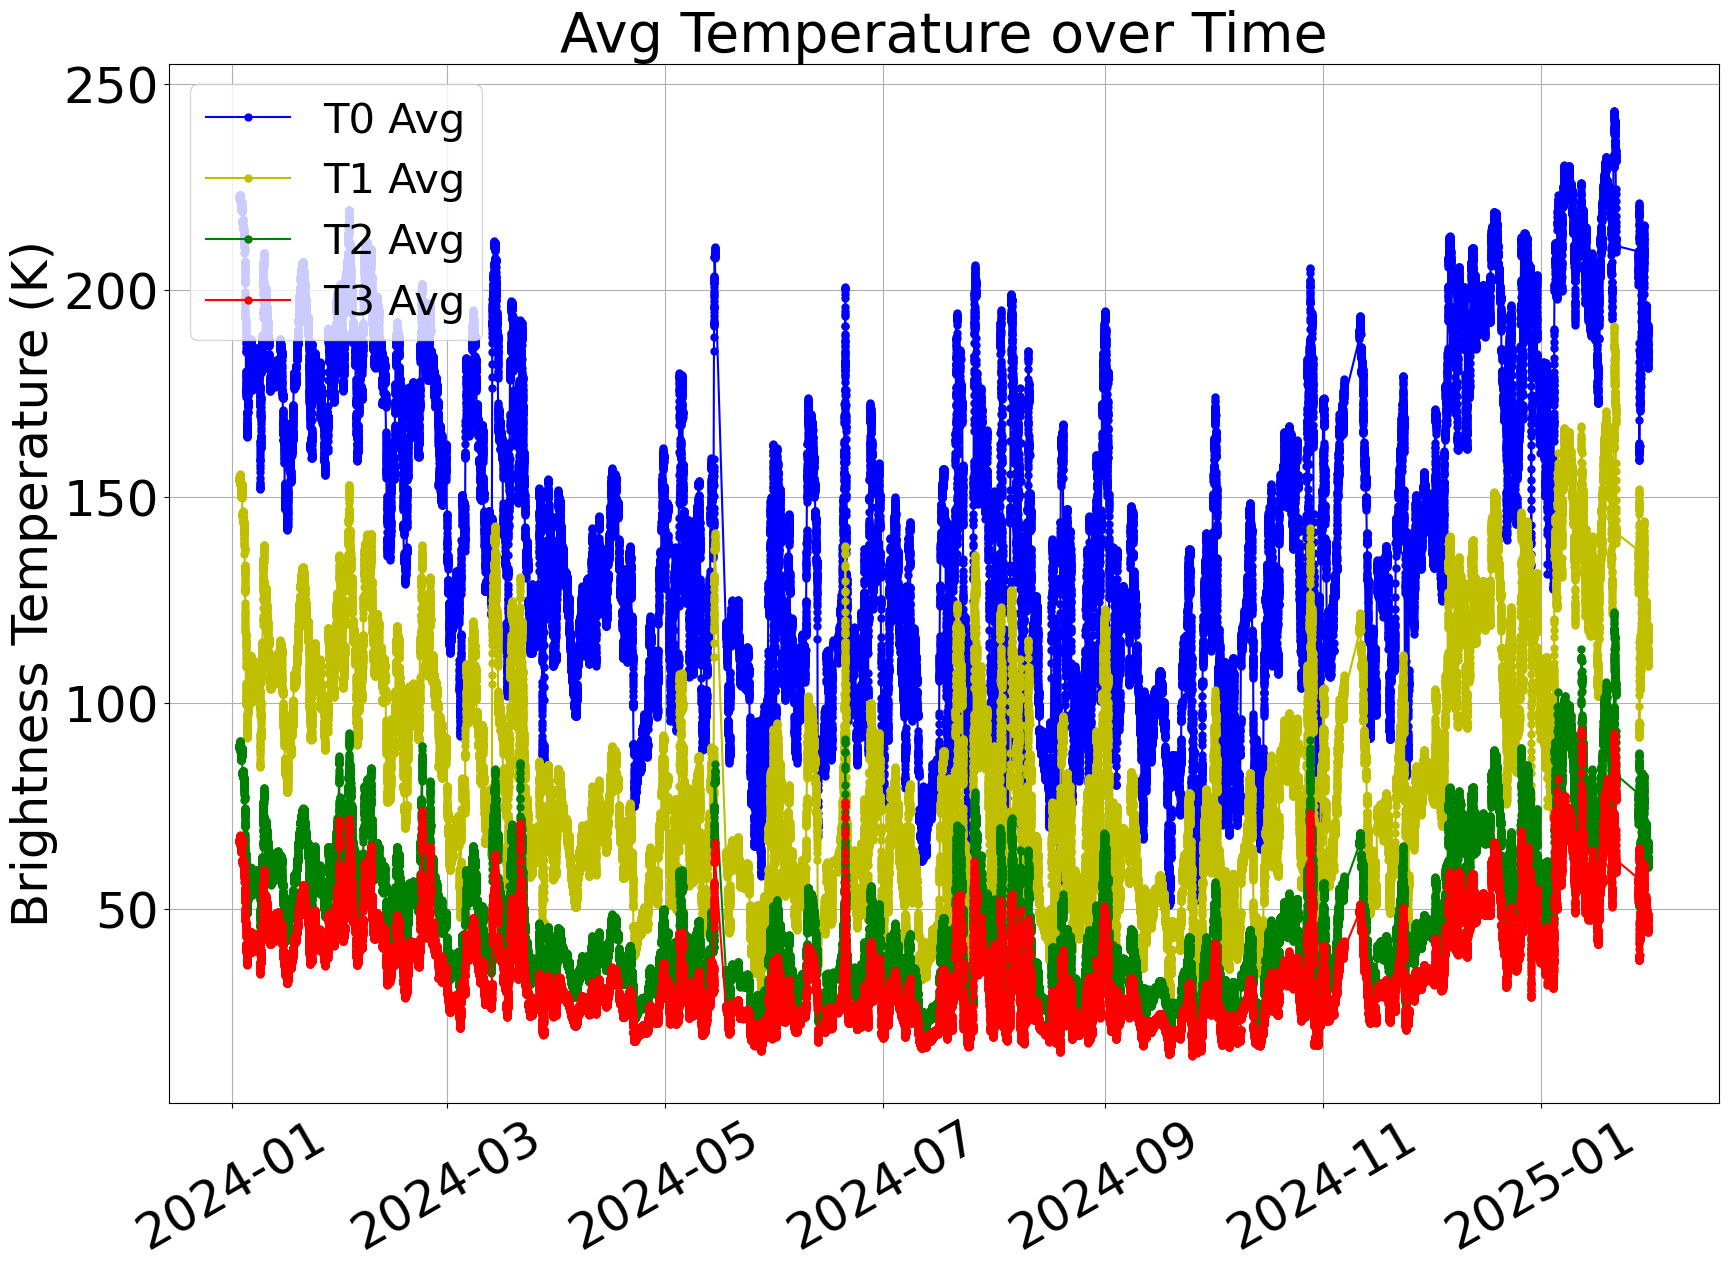

In [1]:
# read npy files 

import numpy as np
import matplotlib.pyplot as plt
# import pandas as pd
import glob
import matplotlib.pyplot as plt
import time
from datetime import datetime
from matplotlib.ticker import MaxNLocator

# 1. Get the list of all .npy file paths
npy_name_list = glob.glob('saveCSV/Pro_*.npy')

# 2. Load each .npy file into a list of arrays
all_arrays = [np.load(f) for f in npy_name_list]

# 3. Concatenate the list of arrays into a single large array
# We use axis=0 to stack them vertically (row-wise)
npy_data = np.concatenate(all_arrays, axis=0)



# save_arr.append([Time_start, Time_end, Time_avg, Time_leap, data_point, 
                #  T0_max, T0_min, T0_avg, T0_median, T0_std, 
                #  T1_max, T1_min, T1_avg, T1_median, T1_std,
                #  T2_max, T2_min, T2_avg, T2_median, T2_std,
                #  T3_max, T3_min, T3_avg, T3_median, T3_std
                #  ])

t_avg = npy_data[:, 2]  # Extract the Time_avg column
# Convert Unix timestamps to readable datetime strings 
# t_mid = [datetime.fromtimestamp(ts).strftime('%Y-%m-%d %H:%M:%S') for ts in t_avg]
t_mid = [datetime.fromtimestamp(ts) for ts in t_avg]

t_leap = npy_data[:, 3]
t_dp = npy_data[:, 4]

T0_max = npy_data[:, 5]
T0_min = npy_data[:, 6]
T0_avg = npy_data[:, 7]
T0_median = npy_data[:, 8]
T0_std = npy_data[:, 9]

T1_max = npy_data[:, 10]
T1_min = npy_data[:, 11]
T1_avg = npy_data[:, 12]
T1_median = npy_data[:, 13]
T1_std = npy_data[:, 14]

T2_max = npy_data[:, 15]
T2_min = npy_data[:, 16]
T2_avg = npy_data[:, 17]
T2_median = npy_data[:, 18]
T2_std = npy_data[:, 19]


T3_max = npy_data[:, 20]
T3_min = npy_data[:, 21]
T3_avg = npy_data[:, 22]
T3_median = npy_data[:, 23]
T3_std = npy_data[:, 24]

# #max
# plt.figure(figsize=(12, 8))
# plt.plot(t_mid, T0_max, label='T0 Max', marker='o', markersize=3, color='b')
# plt.plot(t_mid, T1_max, label='T1 Max', marker='o', markersize=3, color='y')
# plt.plot(t_mid, T2_max, label='T2 Max', marker='o', markersize=3, color='g')
# plt.plot(t_mid, T3_max, label='T3 Max', marker='o', markersize=3, color='r')
# plt.xticks(rotation=45)
# plt.title('Max Temperature over Time', fontsize=24)
# plt.grid(True)
# plt.legend()  
# #plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=10))
# #plt.savefig('saveCSV/plots/max_temp_over_time.png', dpi=300)
# plt.show()

# #hist of T*_max
# plt.figure(figsize=(12, 8))
# plt.hist(T0_max, bins=100, alpha=0.7, label='T0 Max', color='b')
# plt.hist(T1_max, bins=100, alpha=0.7, label='T1 Max', color='y')
# plt.hist(T2_max, bins=100, alpha=0.7, label='T2 Max', color='g')
# plt.hist(T3_max, bins=100, alpha=0.7, label='T3 Max', color='r')
# plt.xlabel('Max Temperature')
# plt.ylabel('Frequency')
# plt.title('Histogram of Max Temperature')
# plt.grid(True)
# plt.legend()    
# #plt.savefig('saveCSV/plots/hist_max_temp.png', dpi=300)
# plt.show()

#min
# plt.figure(figsize=(12, 8))
# plt.plot(t_mid, T0_min, label='T0 Min', marker='o', markersize=3, color='b')
# plt.plot(t_mid, T1_min, label='T1 Min', marker='o', markersize=3, color='y')
# plt.plot(t_mid, T2_min, label='T2 Min', marker='o', markersize=3, color='g')
# plt.plot(t_mid, T3_min, label='T3 Min', marker='o', markersize=3, color='r')
# plt.xticks(rotation=45)
# plt.title('Min Temperature over Time', fontsize=24)
# plt.grid(True)
# plt.legend()  
# #plt.savefig('saveCSV/plots/min_temp_over_time.png', dpi=300)
# plt.show()


# plt.figure(figsize=(12, 8))
# plt.hist(T0_min, bins=100, alpha=0.7, label='T0 Min', color='b')
# plt.hist(T1_min, bins=100, alpha=0.7, label='T1 Min', color='y')
# plt.hist(T2_min, bins=100, alpha=0.7, label='T2 Min', color='g')
# plt.hist(T3_min, bins=100, alpha=0.7, label='T3 Min', color='r')
# plt.xlabel('Min Temperature')
# plt.ylabel('Frequency')
# plt.title('Histogram of Min Temperature')
# plt.grid(True)
# plt.legend()    
# #plt.savefig('saveCSV/plots/hist_min_temp.png', dpi=300)
# plt.show()

#avg
plt.figure(figsize=(40/2, 27/2))
plt.plot(t_mid, T0_avg, label='T0 Avg', marker='o', markersize=5, color='b')
plt.plot(t_mid, T1_avg, label='T1 Avg', marker='o', markersize=5, color='y')
plt.plot(t_mid, T2_avg, label='T2 Avg', marker='o', markersize=5, color='g')
plt.plot(t_mid, T3_avg, label='T3 Avg', marker='o', markersize=5, color='r')
plt.xticks(rotation=30, fontsize=36)
plt.yticks(fontsize=36)
plt.title(f'Avg Temperature over Time', fontsize=40)
#plt.xlabel(f'Data range: {t_mid[0]} → {t_mid[-1]}', fontsize=40)
plt.ylabel('Brightness Temperature (K)', fontsize=36)
plt.grid(True)
plt.legend(loc="upper left", fontsize=30)  
plt.savefig('saveCSV/plots/avg_temp_over_time1007.png', dpi=500)
plt.show()


# plt.figure(figsize=(12, 8))
# plt.hist(T0_avg, bins=100, alpha=0.7, label='T0 Avg', color='b')
# plt.hist(T1_avg, bins=100, alpha=0.7, label='T1 Avg', color='y')
# plt.hist(T2_avg, bins=100, alpha=0.7, label='T2 Avg', color='g')
# plt.hist(T3_avg, bins=100, alpha=0.7, label='T3 Avg', color='r')
# plt.xlabel('Avg Temperature')
# plt.ylabel('Frequency')
# plt.title('Histogram of Avg Temperature')
# plt.grid(True)
# plt.legend()    
# #plt.savefig('saveCSV/plots/hist_avg_temp.png', dpi=300)
# plt.show()

# #median
# plt.figure(figsize=(12, 8))
# plt.plot(t_mid, T0_median, label='T0 Median', marker='o', markersize=3, color='b')
# plt.plot(t_mid, T1_median, label='T1 Median', marker='o', markersize=3, color='y')
# plt.plot(t_mid, T2_median, label='T2 Median', marker='o', markersize=3, color='g')
# plt.plot(t_mid, T3_median, label='T3 Median', marker='o', markersize=3, color='r')
# plt.xticks(rotation=45)
# plt.title('Median Temperature over Time', fontsize=24)
# plt.grid(True)
# plt.legend()  
# #plt.savefig('saveCSV/plots/median_temp_over_time.png', dpi=300)
# plt.show()


# plt.figure(figsize=(12, 8))
# plt.hist(T0_median, bins=100, alpha=0.7, label='T0 Median', color='b')
# plt.hist(T1_median, bins=100, alpha=0.7, label='T1 Median', color='y')
# plt.hist(T2_median, bins=100, alpha=0.7, label='T2 Median', color='g')
# plt.hist(T3_median, bins=100, alpha=0.7, label='T3 Median', color='r')
# plt.xlabel('Median Temperature')
# plt.ylabel('Frequency')
# plt.title('Histogram of Median Temperature')
# plt.grid(True)
# plt.legend()    
# #plt.savefig('saveCSV/plots/hist_median_temp.png', dpi=300)
# plt.show()

# #std σ
# plt.figure(figsize=(40/2, 22/2))
# plt.plot(t_mid, T0_std, label='T0 σ', marker='o', markersize=5, color='b')
# plt.plot(t_mid, T1_std, label='T1 σ', marker='o', markersize=5, color='y')
# plt.plot(t_mid, T2_std, label='T2 σ', marker='o', markersize=5, color='g')
# plt.plot(t_mid, T3_std, label='T3 σ', marker='o', markersize=5, color='r')
# plt.xticks(rotation=40, fontsize=36)
# plt.title('Standard deviation of Temperature over Time', fontsize=44)
# plt.yticks(fontsize=36)
# plt.xlabel(f'Data range: {t_mid[0]} → {t_mid[-1]}', fontsize=40)
# plt.ylabel('Total PWV Zenith (um)', fontsize=40)
# plt.grid(True)
# plt.legend(fontsize=40)  
# plt.savefig('saveCSV/plots/std_temp_over_time1005.png', dpi=500)
# plt.show()


# plt.figure(figsize=(12, 8))
# plt.hist(T0_std, bins=100, alpha=0.7, label='T0 σ', color='b')
# plt.hist(T1_std, bins=100, alpha=0.7, label='T1 σ', color='y')
# plt.hist(T2_std, bins=100, alpha=0.7, label='T2 σ', color='g')
# plt.hist(T3_std, bins=100, alpha=0.7, label='T3 σ', color='r')
# plt.xlabel('standard deviation of Temperature')
# plt.ylabel('Frequency')
# plt.title('Histogram of standard deviation of Temperature')
# plt.grid(True)
# plt.legend()    
# #plt.savefig('saveCSV/plots/hist_std_temp.png', dpi=300)
# plt.show()


# #time leap and data points
# plt.figure(figsize=(12, 8))
# plt.hist(t_leap, bins=100, alpha=0.7, label='Time Leap')
# plt.xlabel('Time Leap')
# plt.ylabel('Frequency')
# plt.title('Histogram of Time Leap')
# plt.grid(True)
# plt.yscale('log')
# plt.legend()
# #plt.savefig('saveCSV/plots/hist_time_leap.png', dpi=300)
# plt.show()

# plt.figure(figsize=(12, 8))
# plt.hist(t_dp, bins=100, alpha=0.7, label='Data Points')
# plt.xlabel('Data Points')
# plt.ylabel('Frequency')
# plt.title('Histogram of Data Points')
# plt.grid(True)
# plt.yscale('log')
# plt.legend()
# #plt.savefig('saveCSV/plots/hist_data_points.png', dpi=300)
# plt.show()

#~40s